In [2]:
from google.colab import drive
drive.mount('/content/drive')
OHIO_ROOT = '/content/drive/MyDrive/bloodglucose'
!pip install -q torch torchvision scikit-learn matplotlib seaborn scipy
print('All dependencies ready')

Mounted at /content/drive
All dependencies ready


In [3]:
import os, glob, shutil, xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
SEQ_LEN  = 24
HORIZON  = 6
T_MC     = 50
EPOCHS   = 50
PATIENCE = 15
LR       = 1e-4
KL_W     = 0.01
DROPOUT  = 0.3
HIDDEN   = 50
N_LAYERS = 3

print(f'Device : {DEVICE}')
print(f'Config : window={SEQ_LEN}, horizon={HORIZON} steps ({HORIZON*5} min)')
print(f'         hidden={HIDDEN}, layers={N_LAYERS}, dropout={DROPOUT}')
print(f'         lr={LR}, kl_weight={KL_W}, MC passes={T_MC}')

Device : cpu
Config : window=24, horizon=6 steps (30 min)
         hidden=50, layers=3, dropout=0.3
         lr=0.0001, kl_weight=0.01, MC passes=50


In [4]:
import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd

def parse_ohio_xml(filepath):
    """Parse one OhioT1DM XML file into a tidy DataFrame."""
    tree = ET.parse(filepath)
    root = tree.getroot()
    patient_id = root.get('id', os.path.basename(filepath))

    rows = []

    glucose_node = root.find('glucose_level')

    if glucose_node is not None:
        for event in glucose_node.findall('event'):
            ts  = event.get('ts')
            val = event.get('value')
            if ts and val:
                try:
                    v = float(val)
                    # Keep only valid blood glucose readings
                    if v > 10:
                        rows.append({
                            'timestamp': pd.to_datetime(ts, dayfirst=True),
                            'glucose': v,
                            'patient': patient_id
                        })
                except ValueError:
                    pass

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values('timestamp').reset_index(drop=True)
    return df

xml_files = glob.glob(os.path.join(OHIO_ROOT, '**', '*.xml'), recursive=True)
print(f'Found {len(xml_files)} XML files')

train_dfs, test_dfs = [], []
for f in xml_files:
    df = parse_ohio_xml(f)
    if len(df) == 0:
        continue
    if 'training' in f.lower():
        train_dfs.append(df)
    elif 'testing' in f.lower():
        test_dfs.append(df)
    else:
        train_dfs.append(df)

if not train_dfs:
    all_dfs = [parse_ohio_xml(f) for f in xml_files]
    combined = pd.concat(all_dfs).sort_values('timestamp').reset_index(drop=True)
    n = int(0.8 * len(combined))
    train_df = combined.iloc[:n].copy()
    test_df  = combined.iloc[n:].copy()
else:
    train_df = pd.concat(train_dfs).sort_values('timestamp').reset_index(drop=True)
    test_df  = (pd.concat(test_dfs).sort_values('timestamp').reset_index(drop=True)
                if test_dfs else train_df.tail(500).copy())

print(f'Train rows: {len(train_df)} | Test rows: {len(test_df)}')
print(f"Patients in train: {train_df['patient'].unique()}")
print(train_df.head(5))

Found 12 XML files
Train rows: 69255 | Test rows: 15970
Patients in train: ['588' '563' '575' '591' '559' '570']
            timestamp  glucose patient
0 2021-08-30 11:53:00    116.0     588
1 2021-08-30 11:58:00    117.0     588
2 2021-08-30 12:03:00    119.0     588
3 2021-08-30 12:08:00    116.0     588
4 2021-08-30 12:13:00    111.0     588


  MLE & MME ESTIMATION
  n (training observations)  = 69255
  MLE  mu                    = 160.1300 mg/dL
  MLE  sigma                 = 60.5376 mg/dL
  MME  mu  (1st moment)      = 160.1300 mg/dL
  MME  sigma (2nd moment)    = 60.5376 mg/dL

  FISHER INFORMATION
  I(mu)        = n/sigma^2   = 18.897350
  I(sigma^2)   = n/(2sig^4)  = 0.00257822
  CRLB for mu  = 1/I(mu)     = 0.052917
  CRLB for s^2 = 1/I(sig^2)  = 387.8639
  FIM:
[[1.88973496e+01 0.00000000e+00]
 [0.00000000e+00 2.57822411e-03]]

  TRANSFORMATION: log(glucose) via Delta Method
  Sample mean log(glucose)   = 5.0018
  Sample std  log(glucose)   = 0.3943
  Delta method SE            = sigma/mu = 0.3781


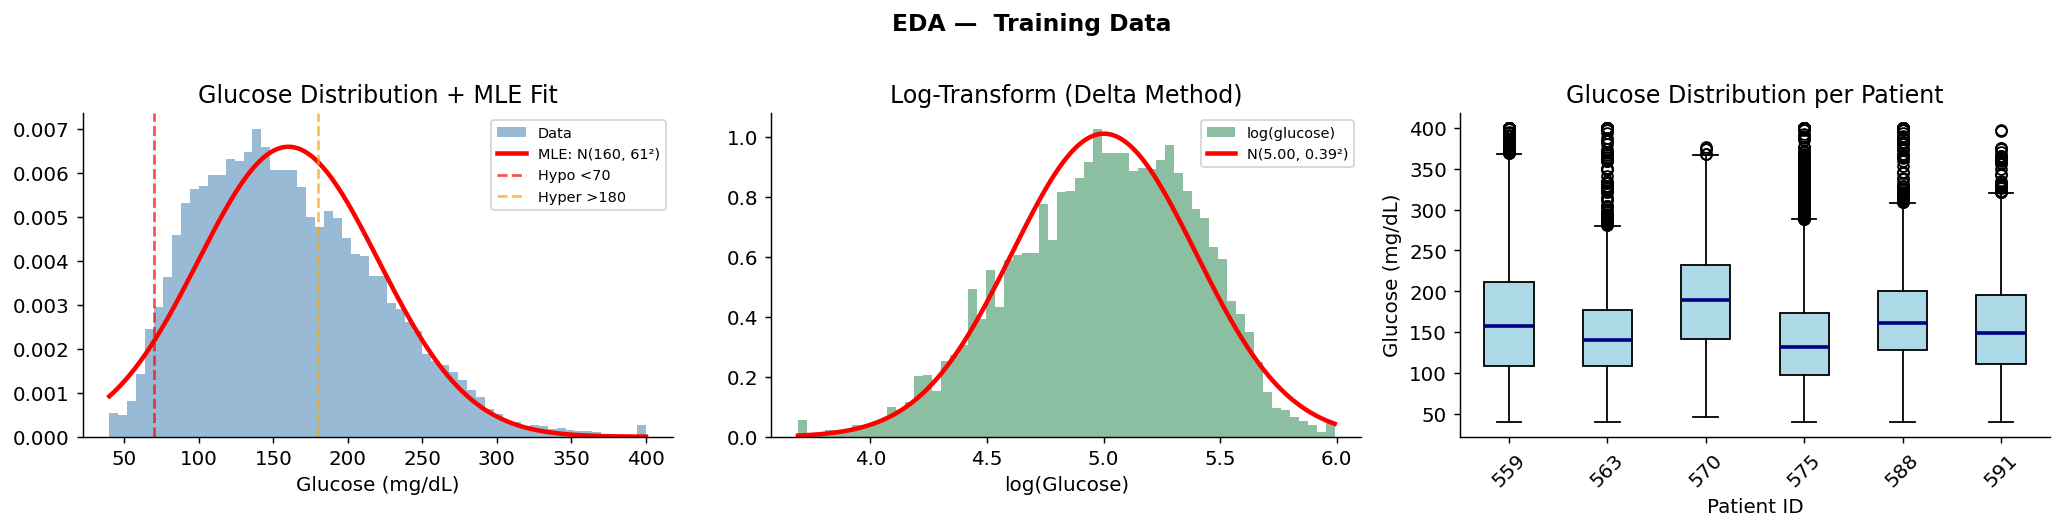

In [5]:
#  EDA + MLE + MME + Fisher Information
glucose = train_df['glucose'].dropna().values
n       = len(glucose)

mu_mle  = np.mean(glucose)
sig_mle = np.std(glucose, ddof=0)

m1      = np.mean(glucose)
m2      = np.mean(glucose**2)
mu_mme  = m1
sig_mme = np.sqrt(np.maximum(m2 - m1**2, 1e-10))


fisher_mu     = n / sig_mle**2
fisher_sigma2 = n / (2 * sig_mle**4)
FIM           = np.diag([fisher_mu, fisher_sigma2])

# Cramer-Rao Lower Bound
CRLB_mu     = 1 / fisher_mu
CRLB_sigma2 = 1 / fisher_sigma2

# Transformation of RV
log_glucose = np.log(glucose[glucose > 0])
mu_log      = np.mean(log_glucose)
sig_log     = np.std(log_glucose)
delta_se    = sig_mle / mu_mle   # delta method approximation
print('='*58)
print('  MLE & MME ESTIMATION')
print('='*58)
print(f'  n (training observations)  = {n}')
print(f'  MLE  mu                    = {mu_mle:.4f} mg/dL')
print(f'  MLE  sigma                 = {sig_mle:.4f} mg/dL')
print(f'  MME  mu  (1st moment)      = {mu_mme:.4f} mg/dL')
print(f'  MME  sigma (2nd moment)    = {sig_mme:.4f} mg/dL')
print()
print('='*58)
print('  FISHER INFORMATION')
print('='*58)
print(f'  I(mu)        = n/sigma^2   = {fisher_mu:.6f}')
print(f'  I(sigma^2)   = n/(2sig^4)  = {fisher_sigma2:.8f}')
print(f'  CRLB for mu  = 1/I(mu)     = {CRLB_mu:.6f}')
print(f'  CRLB for s^2 = 1/I(sig^2)  = {CRLB_sigma2:.4f}')
print(f'  FIM:\n{FIM}')
print()
print('='*58)
print('  TRANSFORMATION: log(glucose) via Delta Method')
print('='*58)
print(f'  Sample mean log(glucose)   = {mu_log:.4f}')
print(f'  Sample std  log(glucose)   = {sig_log:.4f}')
print(f'  Delta method SE            = sigma/mu = {delta_se:.4f}')

# EDA Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# Raw distribution + MLE fit
axes[0].hist(glucose, bins=60, density=True, alpha=0.55, color='steelblue', label='Data')
xr = np.linspace(glucose.min(), glucose.max(), 400)
axes[0].plot(xr, stats.norm.pdf(xr, mu_mle, sig_mle), 'r-', lw=2.5,
             label=f'MLE: N({mu_mle:.0f}, {sig_mle:.0f}²)')
axes[0].axvline(70,  color='red',    ls='--', alpha=0.7, label='Hypo <70')
axes[0].axvline(180, color='orange', ls='--', alpha=0.7, label='Hyper >180')
axes[0].set_title('Glucose Distribution + MLE Fit')
axes[0].set_xlabel('Glucose (mg/dL)')
axes[0].legend(fontsize=8)
# Log-transform
axes[1].hist(log_glucose, bins=60, density=True, alpha=0.55, color='seagreen', label='log(glucose)')
xl = np.linspace(log_glucose.min(), log_glucose.max(), 400)
axes[1].plot(xl, stats.norm.pdf(xl, mu_log, sig_log), 'r-', lw=2.5,
             label=f'N({mu_log:.2f}, {sig_log:.2f}²)')
axes[1].set_title('Log-Transform (Delta Method)')
axes[1].set_xlabel('log(Glucose)')
axes[1].legend(fontsize=8)
# Per-patient boxplot
patients = sorted(train_df['patient'].unique())
data_bp  = [train_df[train_df['patient']==p]['glucose'].dropna().values for p in patients]
axes[2].boxplot(data_bp, labels=patients, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='navy', lw=2))
axes[2].set_title('Glucose Distribution per Patient')
axes[2].set_xlabel('Patient ID')
axes[2].set_ylabel('Glucose (mg/dL)')
axes[2].tick_params(axis='x', rotation=45)
plt.suptitle('EDA —  Training Data', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_01_eda.png', bbox_inches='tight')
plt.show()


[1] Informative Prior: mu0=100.0, tau0=15.0
    Posterior mean (= MAP) = 160.1159 mg/dL
    Posterior median       = 160.1159 mg/dL
    Posterior std tau_n    = 0.230011
    95% Credible Interval  = (159.6651, 160.5667)

[2] Non-Informative Prior: mu0=0.0, tau0=10000.0
    Posterior mean (= MAP) = 160.1300 mg/dL  (≈ MLE = 160.1300)
    95% Credible Interval  = (159.6791, 160.5809)

[3] Jeffreys' Prior: p(mu) ∝ sqrt(I(mu)) = const [improper]
    Posterior mean         = 160.1300 mg/dL  (= MLE)
    Posterior std          = 0.230038
    95% Credible Interval  = (159.6791, 160.5809)

[4] Frequentist 95% CI 
    t_crit = 1.959998
    CI = (159.6791, 160.5809)

=== CI vs CrI Interpretation ===
  Freq CI    (159.68, 160.58): If repeated, 95% of intervals contain true mu
  Bayes CrI  (159.67, 160.57): P(mu in interval | data) = 0.95


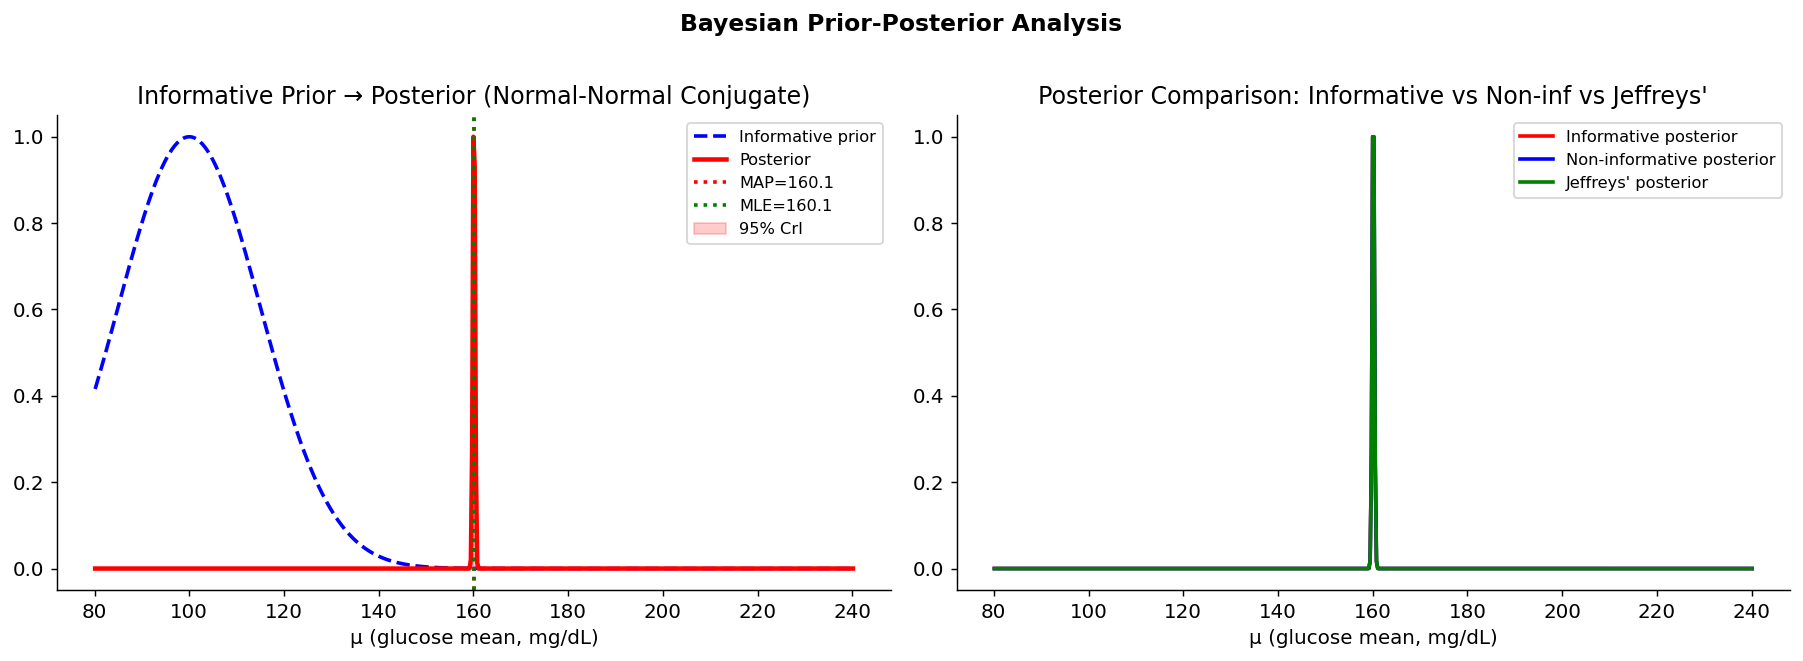

In [7]:
# Bayesian Prior / Posterior Analysis
sigma = sig_mle
x_bar = mu_mle
# Helper: compute Normal-Normal conjugate posterior
def conjugate_posterior(mu0, tau0, x_bar, sigma, n):
    prec_prior = 1/tau0**2
    prec_lik   = n/sigma**2
    tau_n  = np.sqrt(1/(prec_prior + prec_lik))
    mu_n   = (mu0*prec_prior + x_bar*prec_lik)/(prec_prior + prec_lik)
    return mu_n, tau_n

# ── Case 1: Informative Prior ─────────────────────────────────
mu0_inf, tau0_inf = 100.0, 15.0
mu_n_inf, tau_n_inf = conjugate_posterior(mu0_inf, tau0_inf, x_bar, sigma, n)
MAP_inf    = mu_n_inf     # MAP = posterior mean for symmetric Normal
MED_inf    = mu_n_inf     # median = mean for Normal
CrI_inf    = stats.norm.interval(0.95, loc=mu_n_inf, scale=tau_n_inf)

print(f'\n[1] Informative Prior: mu0={mu0_inf}, tau0={tau0_inf}')
print(f'    Posterior mean (= MAP) = {mu_n_inf:.4f} mg/dL')
print(f'    Posterior median       = {MED_inf:.4f} mg/dL')
print(f'    Posterior std tau_n    = {tau_n_inf:.6f}')
print(f'    95% Credible Interval  = ({CrI_inf[0]:.4f}, {CrI_inf[1]:.4f})')
# ── Case 2: Non-Informative Prior ────────────────────────────
mu0_ni, tau0_ni = 0.0, 10000.0
mu_n_ni, tau_n_ni = conjugate_posterior(mu0_ni, tau0_ni, x_bar, sigma, n)
MAP_ni  = mu_n_ni
CrI_ni  = stats.norm.interval(0.95, loc=mu_n_ni, scale=tau_n_ni)

print(f'\n[2] Non-Informative Prior: mu0={mu0_ni}, tau0={tau0_ni}')
print(f'    Posterior mean (= MAP) = {mu_n_ni:.4f} mg/dL  (≈ MLE = {x_bar:.4f})')
print(f'    95% Credible Interval  = ({CrI_ni[0]:.4f}, {CrI_ni[1]:.4f})')

# ── Case 3: Jeffreys' Prior ───────────────────────────────────
mu_jeff   = x_bar
tau_jeff  = sigma / np.sqrt(n)
CrI_jeff  = stats.norm.interval(0.95, loc=mu_jeff, scale=tau_jeff)

print(f"\n[3] Jeffreys' Prior: p(mu) ∝ sqrt(I(mu)) = const [improper]")
print(f'    Posterior mean         = {mu_jeff:.4f} mg/dL  (= MLE)')
print(f'    Posterior std          = {tau_jeff:.6f}')
print(f'    95% Credible Interval  = ({CrI_jeff[0]:.4f}, {CrI_jeff[1]:.4f})')

# ── Frequentist CI via Pivotal Quantity ──────────────────────
S_sample = np.std(glucose, ddof=1)
t_crit   = stats.t.ppf(0.975, df=n-1)
ME       = t_crit * S_sample / np.sqrt(n)
CI_freq  = (x_bar - ME, x_bar + ME)

print(f'\n[4] Frequentist 95% CI ')
print(f'    t_crit = {t_crit:.6f}')
print(f'    CI = ({CI_freq[0]:.4f}, {CI_freq[1]:.4f})')
print(f'\n=== CI vs CrI Interpretation ===')
print(f'  Freq CI    ({CI_freq[0]:.2f}, {CI_freq[1]:.2f}): If repeated, 95% of intervals contain true mu')
print(f'  Bayes CrI  ({CrI_inf[0]:.2f}, {CrI_inf[1]:.2f}): P(mu in interval | data) = 0.95')

# ── Prior-Posterior Plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mu_range  = np.linspace(x_bar - 80, x_bar + 80, 600)
# Left: informative prior vs posterior
prior_inf = stats.norm.pdf(mu_range, mu0_inf, tau0_inf)
post_inf  = stats.norm.pdf(mu_range, mu_n_inf, tau_n_inf)
axes[0].plot(mu_range, prior_inf/prior_inf.max(), 'b--', lw=2, label='Informative prior')
axes[0].plot(mu_range, post_inf/post_inf.max(), 'r-', lw=2.5, label='Posterior')
axes[0].axvline(MAP_inf, color='red',   ls=':', lw=2, label=f'MAP={MAP_inf:.1f}')
axes[0].axvline(x_bar,   color='green', ls=':', lw=2, label=f'MLE={x_bar:.1f}')
axes[0].fill_between(mu_range, post_inf/post_inf.max(),
    where=(mu_range>=CrI_inf[0])&(mu_range<=CrI_inf[1]),
    alpha=0.2, color='red', label='95% CrI')
axes[0].set_title('Informative Prior → Posterior (Normal-Normal Conjugate)')
axes[0].set_xlabel('μ (glucose mean, mg/dL)')
axes[0].legend(fontsize=9)
# Right: all three posteriors compared
post_ni   = stats.norm.pdf(mu_range, mu_n_ni, tau_n_ni)
post_jeff = stats.norm.pdf(mu_range, mu_jeff, tau_jeff)
for p, c, lbl in [(post_inf,'red','Informative posterior'),
                   (post_ni,'blue',"Non-informative posterior"),
                   (post_jeff,'green',"Jeffreys' posterior")]:
    axes[1].plot(mu_range, p/p.max(), lw=2, color=c, label=lbl)
axes[1].set_title("Posterior Comparison: Informative vs Non-inf vs Jeffreys'")
axes[1].set_xlabel('μ (glucose mean, mg/dL)')
axes[1].legend(fontsize=9)
plt.suptitle('Bayesian Prior-Posterior Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_02_bayesian_priors.png', bbox_inches='tight')
plt.show()

In [8]:
# Feature Engineering
def build_features(df, horizon=HORIZON):
    """Build lag + rolling features per patient; target = glucose HORIZON steps ahead."""
    # Ensure it's sorted by patient FIRST, then timestamp
    d = df.copy().sort_values(['patient', 'timestamp']).reset_index(drop=True)

    def engineer_patient(g):
        """Applies features to ONE patient at a time to prevent data leakage."""
        g = g.copy()

        # Interpolate only within this specific patient's timeline
        g['glucose'] = g['glucose'].interpolate(method='linear').ffill().bfill()

        # Lags
        for lag in [1, 2, 3, 6, 12]:
            g[f'lag_{lag}'] = g['glucose'].shift(lag)

        # Rolling
        g['roll_mean_6']  = g['glucose'].rolling(6).mean()
        g['roll_std_6']   = g['glucose'].rolling(6).std()
        g['roll_mean_12'] = g['glucose'].rolling(12).mean()
        g['roll_max_6']   = g['glucose'].rolling(6).max()
        g['roll_min_6']   = g['glucose'].rolling(6).min()

        # Differences
        g['diff_1']       = g['glucose'].diff(1)
        g['diff_6']       = g['glucose'].diff(6)

        # Target (shift backwards to grab future value)
        g['target'] = g['glucose'].shift(-horizon)

        return g

    # Apply the engineering function separately to each patient
    d = d.groupby('patient', group_keys=False).apply(engineer_patient)

    # Time features don't rely on past/future rows, so we can do them globally
    d['hour'] = d['timestamp'].dt.hour
    d['dow']  = d['timestamp'].dt.dayofweek

    # Drop all the NaN rows created by the shifts and rolling windows at the edges
    d = d.dropna().reset_index(drop=True)
    return d

train_feat = build_features(train_df)
test_feat  = build_features(test_df)

FEATURE_COLS = [c for c in train_feat.columns
                if c not in ['timestamp', 'patient', 'glucose', 'target']]

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Train shape: {train_feat.shape} | Test shape: {test_feat.shape}')

Features (14): ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_mean_6', 'roll_std_6', 'roll_mean_12', 'roll_max_6', 'roll_min_6', 'diff_1', 'diff_6', 'hour', 'dow']
Train shape: (69147, 18) | Test shape: (15862, 18)


In [9]:
# Sequence Building & Data Loaders
from sklearn.model_selection import train_test_split

scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit scalers strictly on training data to prevent leakage
scaler_X.fit(train_feat[FEATURE_COLS])
scaler_y.fit(train_feat[['target']])

def build_patient_sequences(df, seq_len):
    """Builds time-series sequences strictly within individual patient timelines."""
    X_all, y_all = [], []

    # Group by patient to prevent cross-patient sequence bleeding
    for patient_id, group in df.groupby('patient'):
        # Transform this specific patient's data
        X_scaled = scaler_X.transform(group[FEATURE_COLS])
        y_scaled = scaler_y.transform(group[['target']]).flatten()

        # Slide the window only within this patient's data
        for i in range(seq_len, len(X_scaled)):
            X_all.append(X_scaled[i-seq_len : i])
            y_all.append(y_scaled[i])

    return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.float32)

# Generate clean sequences
X_tr_full, y_tr_full = build_patient_sequences(train_feat, SEQ_LEN)
X_te, y_te = build_patient_sequences(test_feat, SEQ_LEN)

# Create the 80/20 Train/Validation split
split_idx = int(len(X_tr_full) * 0.8)
X_tr, y_tr   = X_tr_full[:split_idx], y_tr_full[:split_idx]
X_val, y_val = X_tr_full[split_idx:], y_tr_full[split_idx:]

#Create PyTorch Datasets and DataLoaders
train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
val_ds   = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_ds  = TensorDataset(torch.tensor(X_te), torch.tensor(y_te))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

INPUT_SIZE = len(FEATURE_COLS)

print(f" Split -> Train: {X_tr.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_te.shape[0]}")
print(f"Sequence Shape: (Batch Size, {SEQ_LEN} steps, {INPUT_SIZE} features)")

 Split -> Train: 55202 | Validation: 13801 | Test: 15718
Sequence Shape: (Batch Size, 24 steps, 14 features)


In [11]:
#  Save Scalers to Drive
import joblib
SAVE_DIR = '/content/drive/MyDrive/BayesianBiGRU_Outputs'
os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump(scaler_X, f'{SAVE_DIR}/scaler_X.pkl')
joblib.dump(scaler_y, f'{SAVE_DIR}/scaler_y.pkl')

print(f'scaler_X saved  →  mean={scaler_X.mean_[:3]}...')
print(f' scaler_y saved  →  mean={scaler_y.mean_[0]:.4f}, scale={scaler_y.scale_[0]:.4f}')
print(f' Both scalers in: {SAVE_DIR}')

scaler_X saved  →  mean=[160.12755434 160.12437271 160.12111878]...
 scaler_y saved  →  mean=160.1545, scale=60.5553
 Both scalers in: /content/drive/MyDrive/BayesianBiGRU_Outputs


In [12]:
#  Model Architecture
#  1. Bayesian Linear Layer — weight distributions, reparameterisation
#  2. Attention Mechanism   — project (2H→2H) + context (2H→1)
#  3. BiGRU            — BiGRU(3L) → Attention → MC Dropout
#                             → BayesianLinear → (mean, log_var)

# ── Bayesian Linear Layer ─────────────────────────────────────
class BayesianLinear(nn.Module):

    def __init__(self, in_f, out_f):
        super().__init__()
        self.w_mu  = nn.Parameter(torch.zeros(out_f, in_f))
        self.w_rho = nn.Parameter(torch.full((out_f, in_f), -3.0))
        self.b_mu  = nn.Parameter(torch.zeros(out_f))
        self.b_rho = nn.Parameter(torch.full((out_f,), -3.0))
        nn.init.xavier_uniform_(self.w_mu)

    def forward(self, x):
        w_sigma = F.softplus(self.w_rho)
        b_sigma = F.softplus(self.b_rho)
        w = self.w_mu + w_sigma * torch.randn_like(w_sigma)
        b = self.b_mu + b_sigma * torch.randn_like(b_sigma)
        return F.linear(x, w, b)

    def kl_loss(self):
        def kl(mu, rho):
            sigma = F.softplus(rho)
            return -0.5 * torch.sum(1 + 2*torch.log(sigma + 1e-8) - mu**2 - sigma**2)
        return kl(self.w_mu, self.w_rho) + kl(self.b_mu, self.b_rho)

# ── Attention Mechanism ───────────────────────────────────────
class Attention(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()
        self.project = nn.Linear(2*hidden_dim, 2*hidden_dim)
        self.context = nn.Linear(2*hidden_dim, 1, bias=False)

    def forward(self, gru_out):
        # gru_out: (B, T, 2H)
        energy  = torch.tanh(self.project(gru_out))        # (B, T, 2H)
        weights = torch.softmax(self.context(energy), dim=1)  # (B, T, 1)
        context = (weights * gru_out).sum(dim=1)           # (B, 2H)
        return context, weights.squeeze(-1)                 # (B, 2H), (B, T)

class BiGRU(nn.Module):
    def __init__(self, input_size, hidden_dim=HIDDEN,
                 num_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        self.bigru     = nn.GRU(input_size, hidden_dim, num_layers=num_layers,
                                batch_first=True, bidirectional=True, dropout=dropout)
        self.attention = Attention(hidden_dim)
        self.dropout   = nn.Dropout(dropout)
        # Bayesian linear: outputs mean AND log variance
        self.bay_mean  = BayesianLinear(2*hidden_dim, 1)
        self.bay_lv    = BayesianLinear(2*hidden_dim, 1)

    def forward(self, x):
        gru_out, _    = self.bigru(x)          # (B, T, 2H)
        ctx, attn_w   = self.attention(gru_out) # (B, 2H)
        ctx           = self.dropout(ctx)
        mean          = self.bay_mean(ctx).squeeze(-1)  # (B,)
        log_var       = self.bay_lv(ctx).squeeze(-1)    # (B,)
        return mean, log_var

    def kl_loss(self):
        return self.bay_mean.kl_loss() + self.bay_lv.kl_loss()

    def enable_dropout(self):
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()


model = BiGRU(INPUT_SIZE).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: BiGRU | Trainable params: {total_params:,}')
print(model)

Model: BiGRU | Trainable params: 121,604
BiGRU(
  (bigru): GRU(14, 50, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (project): Linear(in_features=100, out_features=100, bias=True)
    (context): Linear(in_features=100, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (bay_mean): BayesianLinear()
  (bay_lv): BayesianLinear()
)


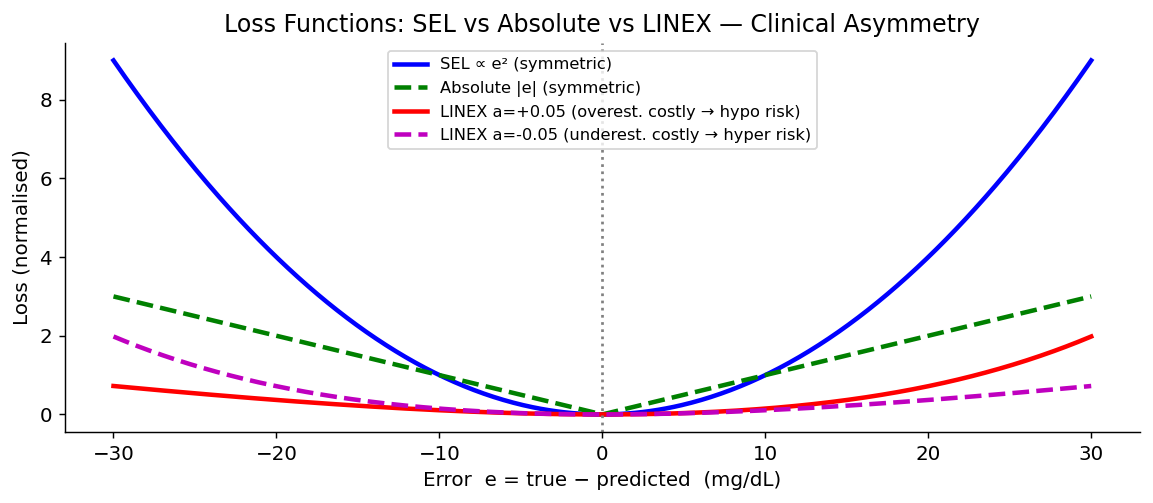

In [14]:
# Loss Functions (NLL + KL) + LINEX
def nll_kl_loss(mean, log_var, target, model, num_batches, kl_weight=KL_W):

    var = torch.exp(log_var).clamp(min=1e-6)

    nll = 0.5 * torch.mean(log_var + (target - mean)**2 / var)

    kl = model.kl_loss() / max(num_batches, 1)

    return nll + kl_weight * kl, nll.item(), kl.item()

def linex_loss(errors, a):

    return np.mean(np.exp(a * errors) - a * errors - 1)

#  LINEX Loss shape plot ─
e_range = np.linspace(-30, 30, 500)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(e_range, e_range**2/100,                      'b-',  lw=2.5, label='SEL ∝ e² (symmetric)')
ax.plot(e_range, np.abs(e_range)/10,                  'g--', lw=2.5, label='Absolute |e| (symmetric)')

ax.plot(e_range, np.array([linex_loss(np.array([ei]), a= 0.05) for ei in e_range]),
        'r-',  lw=2.5, label='LINEX a=+0.05 (overest. costly → hypo risk)')
ax.plot(e_range, np.array([linex_loss(np.array([ei]), a=-0.05) for ei in e_range]),
        'm--', lw=2.5, label='LINEX a=-0.05 (underest. costly → hyper risk)')

ax.axvline(0, color='gray', ls=':')
ax.set_xlabel('Error  e = true − predicted  (mg/dL)')
ax.set_ylabel('Loss (normalised)')
ax.set_title('Loss Functions: SEL vs Absolute vs LINEX — Clinical Asymmetry')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_04_loss_functions.png', bbox_inches='tight')
plt.show()

In [ ]:
#  Training
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=8, factor=0.5)

best_val_loss   = float('inf')
patience_count  = 0
train_losses    = []
val_losses      = []
nll_history     = []
kl_history      = []
best_epoch      = 0

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    ep_loss, ep_nll, ep_kl = 0, 0, 0

    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        mean, log_var = model(Xb)

        loss, nll, kl = nll_kl_loss(mean, log_var, yb, model, len(train_loader))

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        ep_loss += loss.item()
        ep_nll  += nll
        ep_kl   += kl

    # ── Validate ──
    model.eval()
    val_loss_ep = 0
    with torch.no_grad():

        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            mean, log_var = model(Xb)

            l, _, _ = nll_kl_loss(mean, log_var, yb, model, len(val_loader))
            val_loss_ep += l.item()

    tl = ep_loss / len(train_loader)
    vl = val_loss_ep / len(val_loader)

    train_losses.append(tl)
    val_losses.append(vl)
    nll_history.append(ep_nll / len(train_loader))
    kl_history.append(ep_kl  / len(train_loader))

    scheduler.step(vl)

    # ── Early stopping ──
    if vl < best_val_loss:
        best_val_loss  = vl
        patience_count = 0
        best_epoch     = epoch
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\n  Early stopping at epoch {epoch} (best: epoch {best_epoch})')
            break

    if epoch % 10 == 0 or epoch <= 5:
        print(f' Epoch {epoch:3d} | Train: {tl:.5f} | Val: {vl:.5f} | '
              f'NLL: {ep_nll/len(train_loader):.5f} | '
              f'KL: {ep_kl/len(train_loader):.5f} | '
              f'Patience: {patience_count}/{PATIENCE}')

# Load best model
model.load_state_dict(torch.load('best_model.pt'))
print(f'\n Loaded best model from epoch {best_epoch} (val loss={best_val_loss:.5f})')

# ── Training Curve Plot ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ep = range(1, len(train_losses)+1)
axes[0].plot(ep, train_losses, label='Train (NLL+KL)', color='royalblue', lw=2)
axes[0].plot(ep, val_losses,   label='Val  (NLL+KL)', color='orange',    lw=2)
axes[0].axvline(best_epoch, color='green', ls='--', lw=1.5,
                label=f'Best epoch={best_epoch}')
axes[0].set_title('Training Curve — NLL + KL Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NLL + KL Loss')
axes[0].legend()

axes[1].plot(ep, nll_history, label='NLL component', color='tomato',     lw=2)
axes[1].plot(ep, kl_history,  label='KL component',  color='slategray',  lw=2)
axes[1].set_title('NLL vs KL Component History')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss component')
axes[1].legend()

plt.suptitle('Training — BiGRU (NLL+KL, Early Stopping)', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_05_training_curve.png', bbox_inches='tight')
plt.show()
print('Training curve plot saved')

Training PaperBiGRU (NLL+KL loss, early stopping)...
Max epochs=200 | Early stop patience=15 | LR=0.0001
------------------------------------------------------------
 Epoch   1 | Train: -0.14823 | Val: -0.23213 | NLL: -0.15418 | KL: 0.59435 | Patience: 0/15
 Epoch   2 | Train: -0.31392 | Val: -0.29765 | NLL: -0.31987 | KL: 0.59469 | Patience: 0/15
 Epoch   3 | Train: -0.35011 | Val: -0.27893 | NLL: -0.35606 | KL: 0.59507 | Patience: 1/15
 Epoch   4 | Train: -0.36353 | Val: -0.28729 | NLL: -0.36948 | KL: 0.59537 | Patience: 2/15
 Epoch   5 | Train: -0.37328 | Val: -0.31592 | NLL: -0.37924 | KL: 0.59564 | Patience: 0/15
 Epoch  10 | Train: -0.39929 | Val: -0.33895 | NLL: -0.40526 | KL: 0.59688 | Patience: 0/15
 Epoch  20 | Train: -0.44624 | Val: -0.32919 | NLL: -0.45222 | KL: 0.59831 | Patience: 1/15
 Epoch  30 | Train: -0.46266 | Val: -0.37432 | NLL: -0.46865 | KL: 0.59881 | Patience: 2/15
 Epoch  40 | Train: -0.47953 | Val: -0.38018 | NLL: -0.48551 | KL: 0.59867 | Patience: 6/15
 Epoch

KeyboardInterrupt: 

In [15]:
SAVED_MODEL = '/content/drive/MyDrive/BayesianBiGRU_Outputs/best_bigru_model.pt'
if os.path.exists(SAVED_MODEL):
    model = BiGRU(INPUT_SIZE).to(DEVICE)
    model.load_state_dict(torch.load(SAVED_MODEL, map_location=DEVICE))
    model.eval()
    best_epoch = 42
    best_val_loss = -0.393
    print(f'Model loaded from Drive ')
    print(f'   Best epoch={best_epoch} | Val loss={best_val_loss}')
else:
    print('No saved model found')

Model loaded from Drive 
   Best epoch=42 | Val loss=-0.393


In [16]:
model.load_state_dict(torch.load('/content/drive/MyDrive/BayesianBiGRU_Outputs/best_bigru_model.pt'))
model.eval()
print("Best weights loaded. Ready for final evaluation!")

Best weights loaded. Ready for final evaluation!


In [ ]:
#  MC Dropout Inference
def mc_dropout_predict(model, loader, T=T_MC, device=DEVICE):

    model.eval()
    model.enable_dropout()

    all_means, all_vars, all_targets = [], [], []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            batch_m, batch_v = [], []
            for _ in range(T):
                m, lv = model(Xb)
                batch_m.append(m.cpu())
                batch_v.append(torch.exp(lv).cpu())
            all_means.append(torch.stack(batch_m, dim=1))   # (B, T)
            all_vars.append(torch.stack(batch_v, dim=1))    # (B, T)
            all_targets.append(yb)

    means   = torch.cat(all_means,   dim=0)   # (N, T)
    varss   = torch.cat(all_vars,    dim=0)   # (N, T)
    targets = torch.cat(all_targets, dim=0)   # (N,)

    pred_mean  = means.mean(dim=1).numpy()    # posterior mean
    epistemic  = means.var(dim=1).numpy()     # variance of T means
    aleatoric  = varss.mean(dim=1).numpy()    # mean of T variances
    total_var  = epistemic + aleatoric
    total_std  = np.sqrt(np.abs(total_var))

    return pred_mean, epistemic, aleatoric, total_std, targets.numpy()


preds_sc, epist_sc, aleat_sc, total_std_sc, true_sc = mc_dropout_predict(
    model, test_loader, T=T_MC)

# ── Inverse transform to original glucose scale ───────────────
sigma_y    = scaler_y.scale_[0]
mu_y       = scaler_y.mean_[0]

preds      = scaler_y.inverse_transform(preds_sc.reshape(-1,1)).flatten()
true       = scaler_y.inverse_transform(true_sc.reshape(-1,1)).flatten()
epist_orig = epist_sc * sigma_y**2
aleat_orig = aleat_sc * sigma_y**2
total_orig = total_std_sc * sigma_y    # std in mg/dL
epist_std  = np.sqrt(np.abs(epist_orig))
aleat_std  = np.sqrt(np.abs(aleat_orig))

print(f'MC Dropout: {T_MC} forward passes completed')
print(f'Posterior mean range : [{preds.min():.1f}, {preds.max():.1f}] mg/dL')
print(f'Epistemic std range  : [{epist_std.min():.3f}, {epist_std.max():.3f}] mg/dL')
print(f'Aleatoric std range  : [{aleat_std.min():.3f}, {aleat_std.max():.3f}] mg/dL')
print(f'Total std range      : [{total_orig.min():.3f}, {total_orig.max():.3f}] mg/dL')

MC Dropout: 50 forward passes completed
Posterior mean range : [56.4, 383.8] mg/dL
Epistemic std range  : [1.673, 25.018] mg/dL
Aleatoric std range  : [9.368, 109.095] mg/dL
Total std range      : [10.656, 109.658] mg/dL


In [ ]:
residuals = true - preds
# Standard metrics
MSE  = mean_squared_error(true, preds)
RMSE = np.sqrt(MSE)
MAE  = mean_absolute_error(true, preds)
R2   = r2_score(true, preds)
MARD = np.mean(np.abs(residuals) / np.abs(true + 1e-8)) * 100

#  LINEX Loss
a_pos = 0.05
a_neg = -0.05
LINEX_pos = linex_loss(residuals, a_pos)
LINEX_neg = linex_loss(residuals, a_neg)

# LINEX Bayes Estimator
preds_LINEX_pos = preds - (a_pos/2) * total_orig**2
preds_LINEX_neg = preds - (a_neg/2) * total_orig**2
RMSE_LINEX_pos  = np.sqrt(mean_squared_error(true, preds_LINEX_pos))
MAE_LINEX_pos   = mean_absolute_error(true, preds_LINEX_pos)

# Uncertainty Coverage
within_1sigma = np.mean(np.abs(residuals) <= 1*total_orig) * 100
within_2sigma = np.mean(np.abs(residuals) <= 2*total_orig) * 100
within_3sigma = np.mean(np.abs(residuals) <= 3*total_orig) * 100

# Uncertainty-Error Correlation
abs_err = np.abs(residuals)
corr_epist, pval_e = stats.pearsonr(abs_err, epist_std)
corr_aleat, pval_a = stats.pearsonr(abs_err, aleat_std)
corr_total, pval_t = stats.pearsonr(abs_err, total_orig)

#  Glycaemic range breakdown
hypo_mask  = true < 70
norm_mask  = (true >= 70) & (true <= 180)
hyper_mask = true > 180

def range_metrics(mask, label):
    if mask.sum() == 0:
        return
    print(f'  [{label:10s}]  n={mask.sum():5d} ({100*mask.mean():.1f}%)  '
          f'RMSE={np.sqrt(mean_squared_error(true[mask],preds[mask])):.2f}  '
          f'MAE={mean_absolute_error(true[mask],preds[mask]):.2f}  '
          f'Tot-unc={total_orig[mask].mean():.2f}  '
          f'Epist={epist_std[mask].mean():.2f}  '
          f'Aleat={aleat_std[mask].mean():.2f}')

print('='*65)
print('  FINAL METRICS SUMMARY —BiGRU')
print('='*65)
print(f'  MSE  (SEL)               = {MSE:.4f}  (mg/dL)²')
print(f'  RMSE                     = {RMSE:.4f}  mg/dL  ')
print(f'  MAE  (Abs Error Loss)    = {MAE:.4f}  mg/dL')
print(f'  MARD                     = {MARD:.2f}  %')
print(f'  R²                       = {R2:.4f}')
print()
print(f'  LINEX (a=+0.05, over)    = {LINEX_pos:.6f}')
print(f'  LINEX (a=-0.05, under)   = {LINEX_neg:.6f}')
print(f'  RMSE  (LINEX a=+0.05)    = {RMSE_LINEX_pos:.4f}  mg/dL')
print(f'  MAE   (LINEX a=+0.05)    = {MAE_LINEX_pos:.4f}  mg/dL')
print()
print('  UNCERTAINTY CALIBRATION:')
print(f'  Coverage ±1σ             = {within_1sigma:.2f}%  [expected 68%]')
print(f'  Coverage ±2σ             = {within_2sigma:.2f}%  [expected 95%]')
print(f'  Coverage ±3σ             = {within_3sigma:.2f}%  [expected 99.7%]')
print()
print('  UNCERTAINTY-ERROR CORRELATION:')
print(f'  r(|err|, epistemic)      = {corr_epist:.4f}  (p={pval_e:.4e})')
print(f'  r(|err|, aleatoric)      = {corr_aleat:.4f}  (p={pval_a:.4e})')
print(f'  r(|err|, total)          = {corr_total:.4f}  (p={pval_t:.4e})')
print()
print('  GLYCAEMIC RANGE BREAKDOWN :')
range_metrics(hypo_mask,  'Hypo <70')
range_metrics(norm_mask,  '70-180')
range_metrics(hyper_mask, 'Hyper>180')
print('='*65)

  FINAL METRICS SUMMARY — PaperBiGRU
  MSE  (SEL)               = 485.6259  (mg/dL)²
  RMSE                     = 22.0369  mg/dL   [paper: 22.21]
  MAE  (Abs Error Loss)    = 15.4926  mg/dL
  MARD                     = 10.17  %
  R²                       = 0.8719

  LINEX (a=+0.05, over)    = 2.590918
  LINEX (a=-0.05, under)   = 2.155895
  RMSE  (LINEX a=+0.05)    = 32.3842  mg/dL
  MAE   (LINEX a=+0.05)    = 21.7778  mg/dL

  UNCERTAINTY CALIBRATION:
  Coverage ±1σ             = 80.57%  [expected 68%]
  Coverage ±2σ             = 96.65%  [expected 95%, paper: 98.62%]
  Coverage ±3σ             = 99.20%  [expected 99.7%]

  UNCERTAINTY-ERROR CORRELATION:
  r(|err|, epistemic)      = 0.0192  (p=1.6154e-02)
  r(|err|, aleatoric)      = 0.3568  (p=0.0000e+00)
  r(|err|, total)          = 0.3524  (p=0.0000e+00) [paper: 0.15]

  GLYCAEMIC RANGE BREAKDOWN (like paper Table I):
  [Hypo <70  ]  n=  366 (2.3%)  RMSE=22.87  MAE=19.27  Tot-unc=23.92  Epist=7.08  Aleat=22.73
  [70-180    ]  n= 87

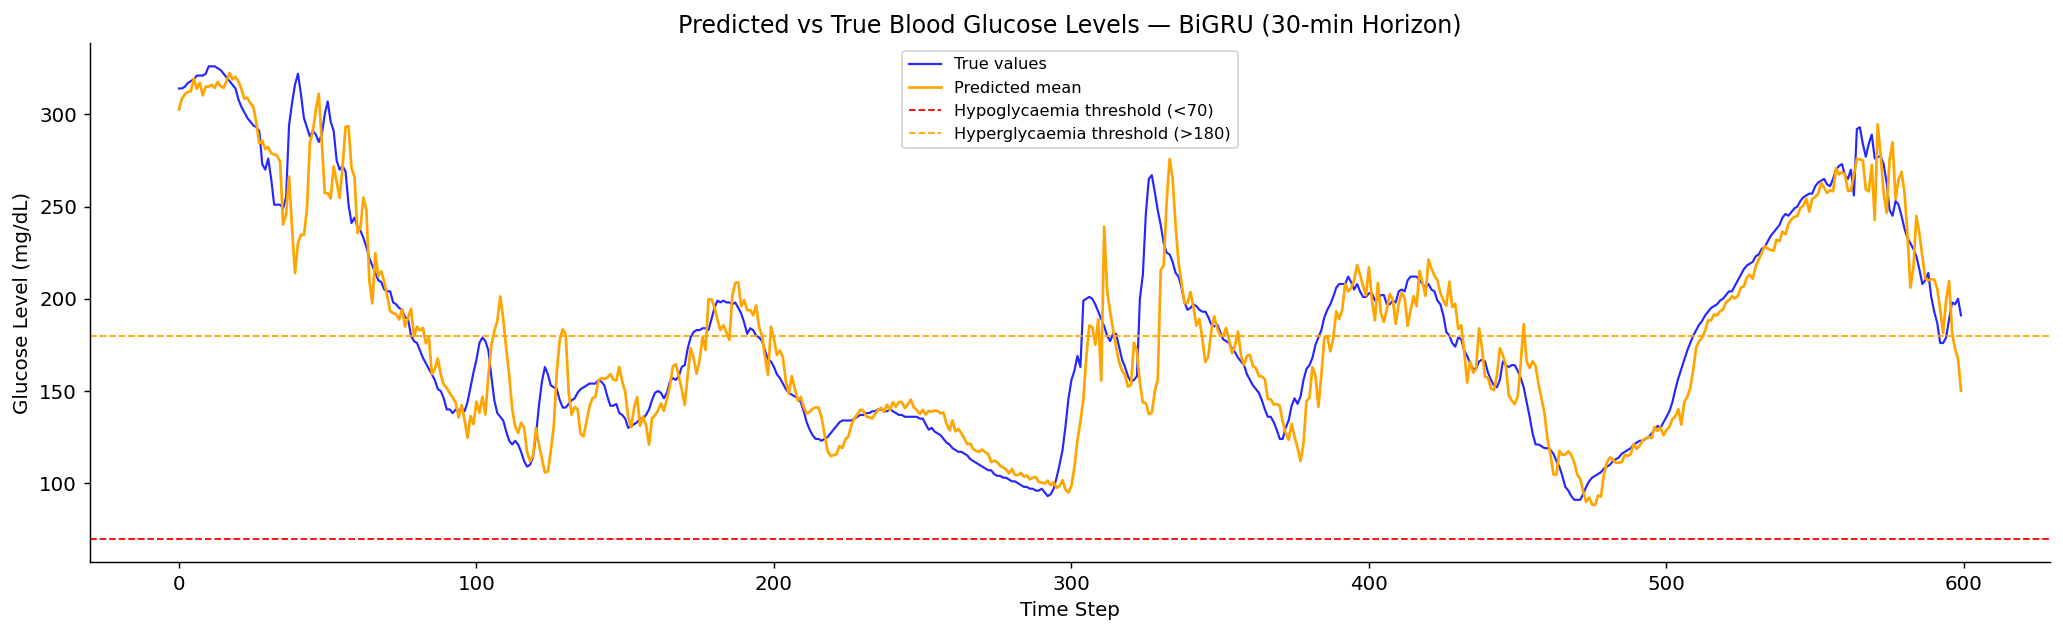

📊 Plot 6: Predicted vs True saved (paper Fig 2 equivalent)


In [ ]:
#PLOT: Predicted vs True
N_PLOT = min(600, len(preds))
t_idx  = np.arange(N_PLOT)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t_idx, true[:N_PLOT],  'b-', lw=1.2, label='True values',    alpha=0.85)
ax.plot(t_idx, preds[:N_PLOT], color='orange', lw=1.5, label='Predicted mean')
ax.axhline(70,  color='red',    ls='--', lw=1, label='Hypoglycaemia threshold (<70)')
ax.axhline(180, color='orange', ls='--', lw=1, label='Hyperglycaemia threshold (>180)')
ax.set_xlabel('Time Step')
ax.set_ylabel('Glucose Level (mg/dL)')
ax.set_title('Predicted vs True Blood Glucose Levels — BiGRU (30-min Horizon)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_06_pred_vs_true.png', bbox_inches='tight')
plt.show()
print(' Plot 6: Predicted vs True saved')

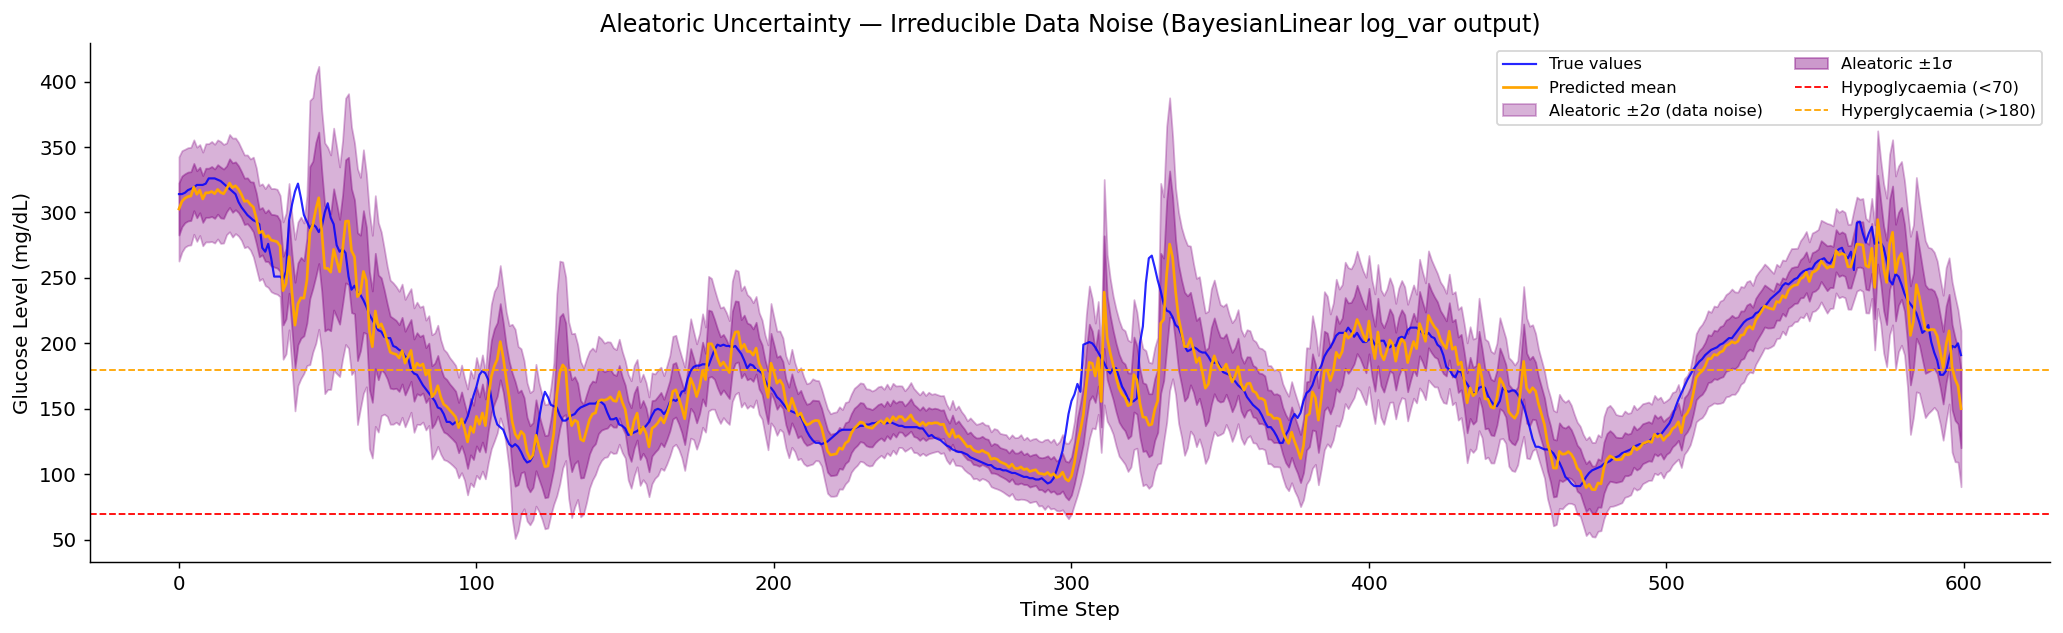

📊 Plot 7: Aleatoric uncertainty saved (paper Fig 3 equivalent)


In [ ]:
# PLOT: Aleatoric Uncertainty Bands
N_PLOT = min(600, len(preds))
t_idx  = np.arange(N_PLOT)
p_plot = preds[:N_PLOT]
t_plot = true[:N_PLOT]
a_plot = aleat_std[:N_PLOT]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t_idx, t_plot, 'b-', lw=1.2, label='True values',    alpha=0.85)
ax.plot(t_idx, p_plot, color='orange', lw=1.5, label='Predicted mean')
ax.fill_between(t_idx, p_plot - 2*a_plot, p_plot + 2*a_plot,
                alpha=0.3, color='purple', label='Aleatoric ±2σ (data noise)')
ax.fill_between(t_idx, p_plot - 1*a_plot, p_plot + 1*a_plot,
                alpha=0.4, color='purple', label='Aleatoric ±1σ')
ax.axhline(70,  color='red',    ls='--', lw=1, label='Hypoglycaemia (<70)')
ax.axhline(180, color='orange', ls='--', lw=1, label='Hyperglycaemia (>180)')
ax.set_xlabel('Time Step')
ax.set_ylabel('Glucose Level (mg/dL)')
ax.set_title('Aleatoric Uncertainty — Irreducible Data Noise (BayesianLinear log_var output)')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('plot_07_aleatoric.png', bbox_inches='tight')
plt.show()
print('Plot 7: Aleatoric uncertainty saved ')

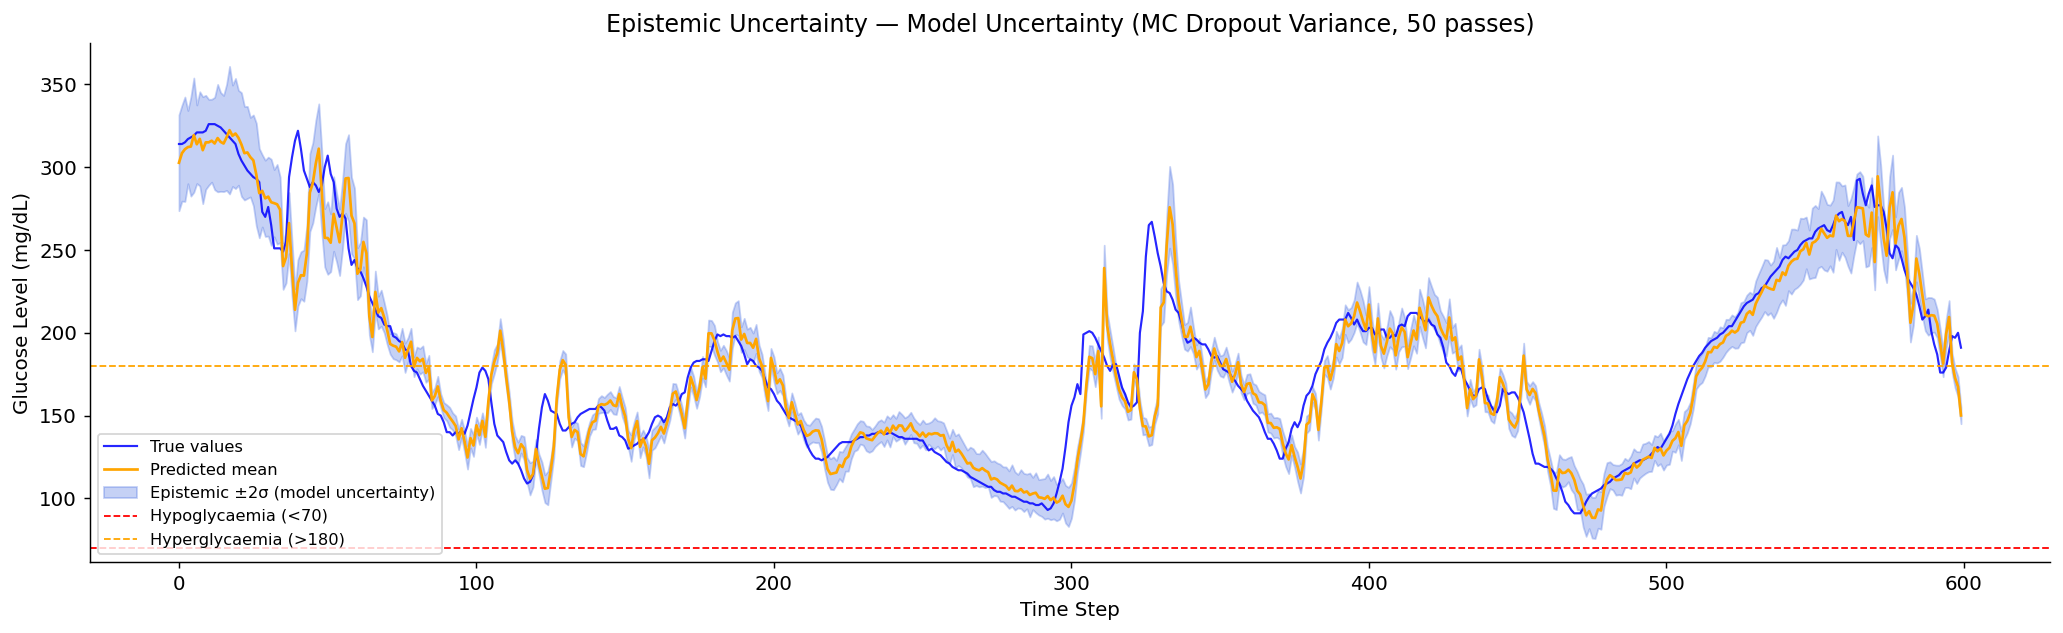

📊 Plot 8: Epistemic uncertainty saved (paper Fig 4 equivalent)


In [ ]:
#  PLOT: Epistemic Uncertainty Bands
e_plot = epist_std[:N_PLOT]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t_idx, t_plot, 'b-', lw=1.2, label='True values',    alpha=0.85)
ax.plot(t_idx, p_plot, color='orange', lw=1.5, label='Predicted mean')
ax.fill_between(t_idx, p_plot - 2*e_plot, p_plot + 2*e_plot,
                alpha=0.3, color='royalblue', label='Epistemic ±2σ (model uncertainty)')
ax.axhline(70,  color='red',    ls='--', lw=1, label='Hypoglycaemia (<70)')
ax.axhline(180, color='orange', ls='--', lw=1, label='Hyperglycaemia (>180)')
ax.set_xlabel('Time Step')
ax.set_ylabel('Glucose Level (mg/dL)')
ax.set_title('Epistemic Uncertainty — Model Uncertainty (MC Dropout Variance, 50 passes)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('plot_08_epistemic.png', bbox_inches='tight')
plt.show()
print(' Plot 8: Epistemic uncertainty saved (paper Fig 4 equivalent)')

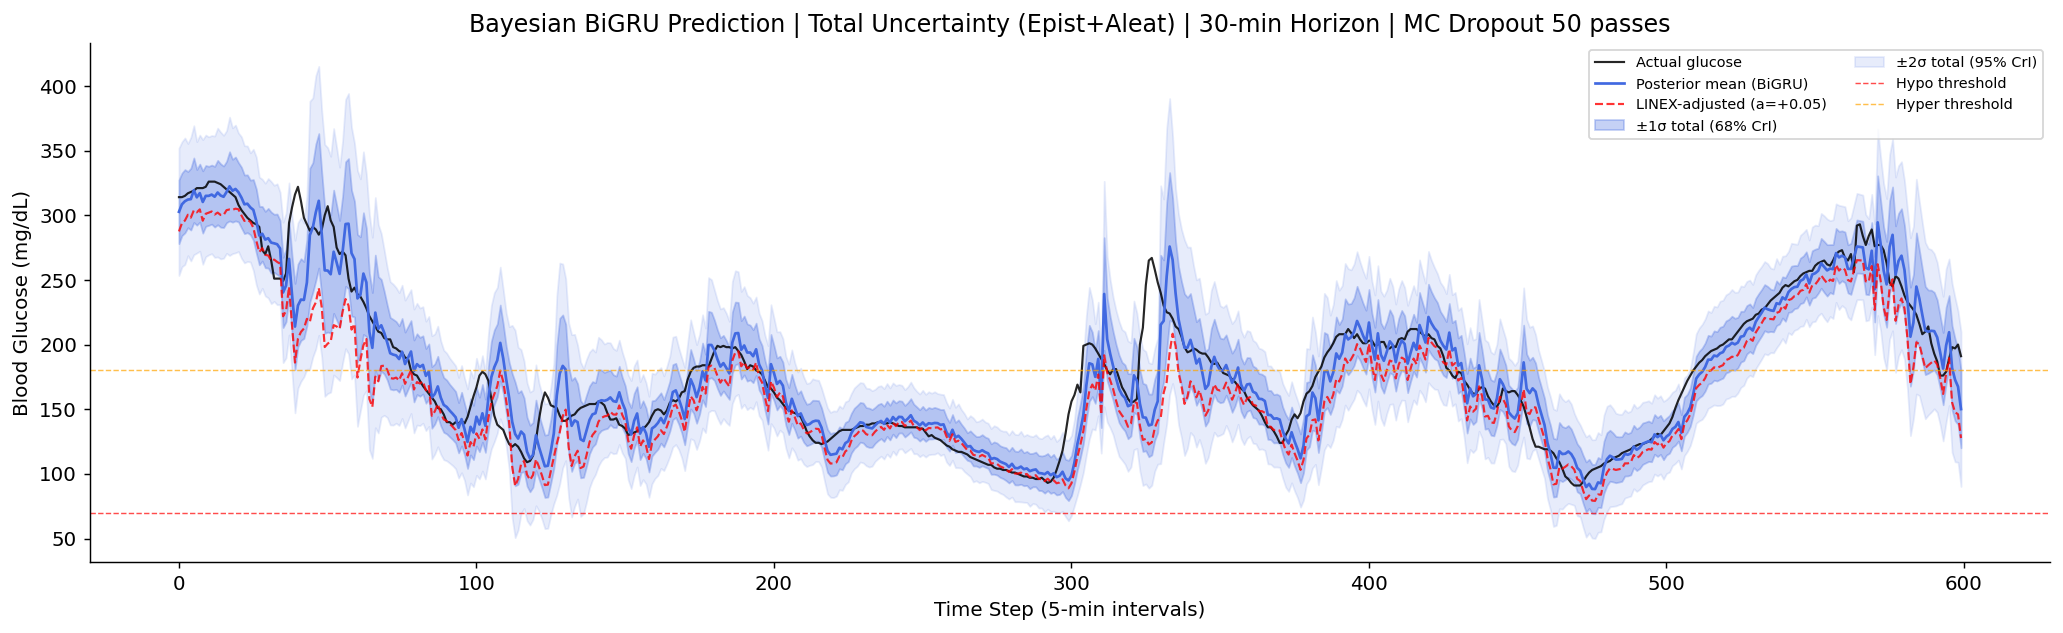

📊 Plot 9: Total uncertainty prediction saved


In [ ]:
#   PLOT: Total Uncertainty + LINEX-adjusted prediction
#             (Bayesian Prediction with full uncertainty band)
tot_plot  = total_orig[:N_PLOT]
linex_plot= preds_LINEX_pos[:N_PLOT]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(t_idx, t_plot,    'k-',     lw=1.2, label='Actual glucose',          alpha=0.85)
ax.plot(t_idx, p_plot,    'royalblue', lw=1.5, label='Posterior mean (BiGRU)')
ax.plot(t_idx, linex_plot,'r--',    lw=1.2, alpha=0.8, label='LINEX-adjusted (a=+0.05)')
ax.fill_between(t_idx, p_plot - 1*tot_plot, p_plot + 1*tot_plot,
                alpha=0.30, color='royalblue', label='±1σ total (68% CrI)')
ax.fill_between(t_idx, p_plot - 2*tot_plot, p_plot + 2*tot_plot,
                alpha=0.12, color='royalblue', label='±2σ total (95% CrI)')
ax.axhline(70,  color='red',    ls='--', lw=0.8, alpha=0.7, label='Hypo threshold')
ax.axhline(180, color='orange', ls='--', lw=0.8, alpha=0.7, label='Hyper threshold')
ax.set_xlabel('Time Step (5-min intervals)')
ax.set_ylabel('Blood Glucose (mg/dL)')
ax.set_title(f'Bayesian BiGRU Prediction | Total Uncertainty (Epist+Aleat) | 30-min Horizon | MC Dropout {T_MC} passes')
ax.legend(fontsize=8, ncol=2, loc='upper right')
plt.tight_layout()
plt.savefig('plot_09_total_uncertainty.png', bbox_inches='tight')
plt.show()
print('Plot 9: Total uncertainty prediction saved')

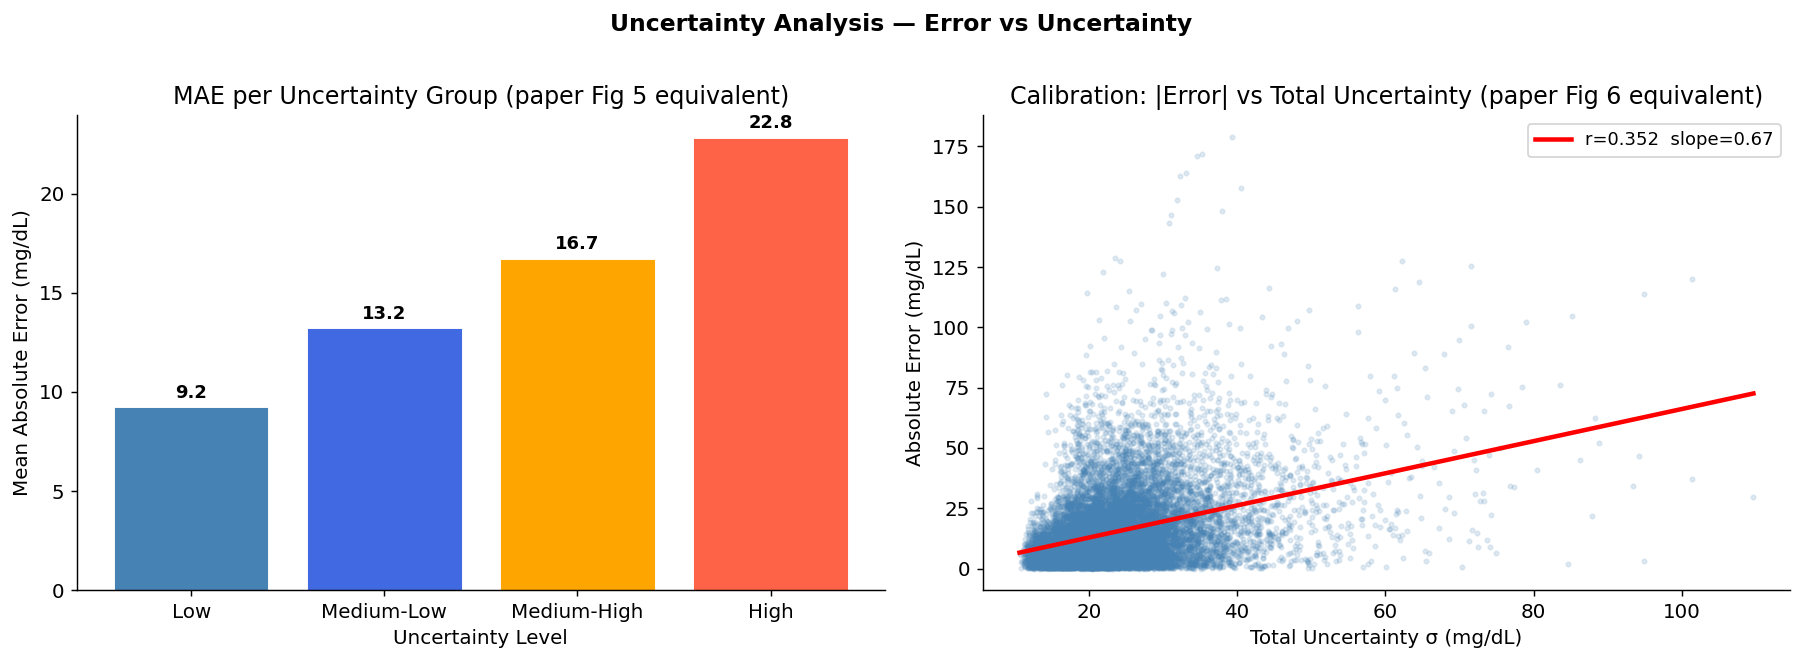

📊 Plot 10: Error vs uncertainty saved (paper Fig 5 & 6 equivalent)


In [ ]:
# PLOT: Error vs Uncertainty Groups
#             + Calibration Scatter
q_edges  = np.percentile(total_orig, [0, 25, 50, 75, 100])
labels   = ['Low', 'Medium-Low', 'Medium-High', 'High']
groups   = np.digitize(total_orig, q_edges[1:-1])
group_mae = [mean_absolute_error(true[groups==g], preds[groups==g])
             if (groups==g).sum() > 0 else 0 for g in range(4)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar: MAE per uncertainty group
bars = axes[0].bar(labels, group_mae, color=['steelblue','royalblue','orange','tomato'],
                   edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, group_mae):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, f'{val:.1f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('MAE per Uncertainty Group (paper Fig 5 equivalent)')
axes[0].set_xlabel('Uncertainty Level')
axes[0].set_ylabel('Mean Absolute Error (mg/dL)')

# Scatter: |error| vs total uncertainty
axes[1].scatter(total_orig, abs_err, alpha=0.15, s=6, color='steelblue')
z_fit = np.polyfit(total_orig, abs_err, 1)
xfit  = np.linspace(total_orig.min(), total_orig.max(), 300)
axes[1].plot(xfit, np.polyval(z_fit, xfit), 'r-', lw=2.5,
             label=f'r={corr_total:.3f}  slope={z_fit[0]:.2f}')
axes[1].set_title('Calibration: |Error| vs Total Uncertainty')
axes[1].set_xlabel('Total Uncertainty σ (mg/dL)')
axes[1].set_ylabel('Absolute Error (mg/dL)')
axes[1].legend(fontsize=10)

plt.suptitle('Uncertainty Analysis — Error vs Uncertainty', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_10_error_vs_uncertainty.png', bbox_inches='tight')
plt.show()
print(' Plot 10: Error vs uncertainty saved')

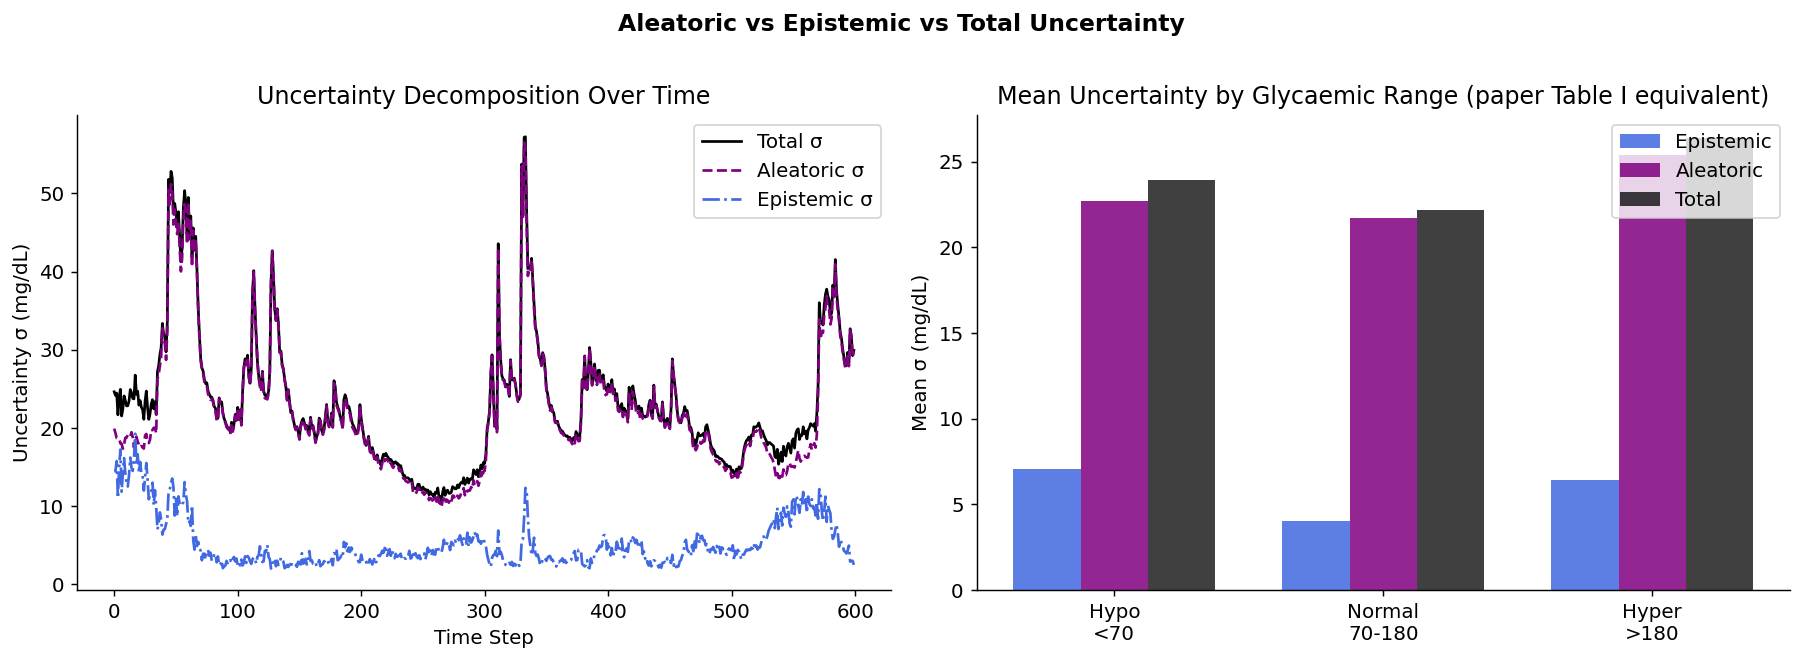

📊 Plot 11: Uncertainty decomposition saved


In [ ]:
#  PLOT: Aleatoric vs Epistemic vs Total decomposition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time-series of three uncertainty components
axes[0].plot(t_idx, tot_plot,           color='black',    lw=1.5, label='Total σ')
axes[0].plot(t_idx, aleat_std[:N_PLOT], color='purple',   lw=1.5, ls='--', label='Aleatoric σ')
axes[0].plot(t_idx, epist_std[:N_PLOT], color='royalblue',lw=1.5, ls='-.', label='Epistemic σ')
axes[0].set_title('Uncertainty Decomposition Over Time')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Uncertainty σ (mg/dL)')
axes[0].legend()

# Glycaemic range: average uncertainty breakdown
rng_labels = []
rng_epist  = []
rng_aleat  = []
rng_total  = []
for mask, lbl in [(hypo_mask,'Hypo\n<70'), (norm_mask,'Normal\n70-180'), (hyper_mask,'Hyper\n>180')]:
    if mask.sum() > 0:
        rng_labels.append(lbl)
        rng_epist.append(epist_std[mask].mean())
        rng_aleat.append(aleat_std[mask].mean())
        rng_total.append(total_orig[mask].mean())

x_pos = np.arange(len(rng_labels))
w = 0.25
axes[1].bar(x_pos - w, rng_epist, w, label='Epistemic', color='royalblue', alpha=0.85)
axes[1].bar(x_pos,     rng_aleat, w, label='Aleatoric', color='purple',    alpha=0.85)
axes[1].bar(x_pos + w, rng_total, w, label='Total',     color='black',     alpha=0.75)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(rng_labels)
axes[1].set_title('Mean Uncertainty by Glycaemic Range (paper Table I equivalent)')
axes[1].set_ylabel('Mean σ (mg/dL)')
axes[1].legend()

plt.suptitle('Aleatoric vs Epistemic vs Total Uncertainty', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_11_uncertainty_decomposition.png', bbox_inches='tight')
plt.show()
print(' Uncertainty decomposition saved')

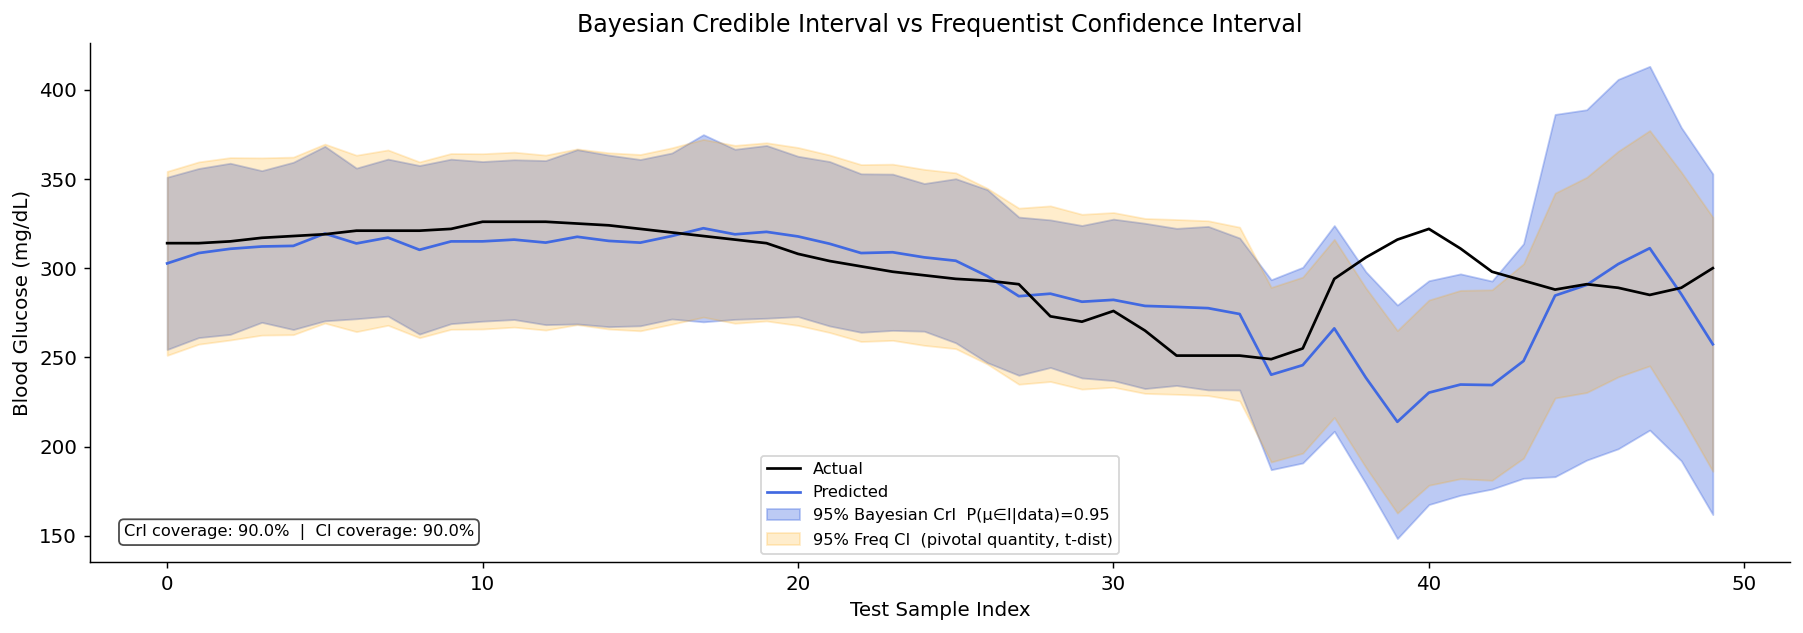

📊 Plot 12: CI vs CrI saved
  Bayesian CrI: P(true glucose in interval | data) = 0.95
  Frequentist CI: 95% of such intervals (if repeated) contain true mean
  Window coverage — CrI: 90.0%  |  CI: 90.0%


In [ ]:
# CI vs CrI Comparison
N_CMP = min(50, len(preds))
idx   = np.arange(N_CMP)

# Bayesian 95% CrI: posterior_mean ± 1.96 * total_std
CrI_lo = preds[:N_CMP] - 1.96 * total_orig[:N_CMP]
CrI_hi = preds[:N_CMP] + 1.96 * total_orig[:N_CMP]

# Frequentist 95% CI
n_roll = 20
se_arr = np.array([total_orig[max(0,i-n_roll):i+1].mean() for i in range(N_CMP)])
t_crit_pt = stats.t.ppf(0.975, df=n_roll-1)
CI_lo = preds[:N_CMP] - t_crit_pt * se_arr
CI_hi = preds[:N_CMP] + t_crit_pt * se_arr

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(idx, true[:N_CMP],  'k-', lw=1.5, label='Actual',    zorder=5)
ax.plot(idx, preds[:N_CMP], 'royalblue', lw=1.5, label='Predicted', zorder=4)
ax.fill_between(idx, CrI_lo, CrI_hi, alpha=0.35, color='royalblue',
                label='95% Bayesian CrI  P(μ∈I|data)=0.95')
ax.fill_between(idx, CI_lo,  CI_hi,  alpha=0.20, color='orange',
                label='95% Freq CI  (pivotal quantity, t-dist)')
ax.set_title('Bayesian Credible Interval vs Frequentist Confidence Interval')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Blood Glucose (mg/dL)')
ax.legend(fontsize=9)

in_cri = np.mean((true[:N_CMP]>=CrI_lo) & (true[:N_CMP]<=CrI_hi)) * 100
in_ci  = np.mean((true[:N_CMP]>=CI_lo)  & (true[:N_CMP]<=CI_hi))  * 100
ax.text(0.02, 0.05, f'CrI coverage: {in_cri:.1f}%  |  CI coverage: {in_ci:.1f}%',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
plt.tight_layout()
plt.savefig('plot_12_ci_vs_cri.png', bbox_inches='tight')
plt.show()

print(' Plot 12: CI vs CrI saved')
print(f'  Bayesian CrI: P(true glucose in interval | data) = 0.95')
print(f'  Frequentist CI: 95% of such intervals (if repeated) contain true mean')
print(f'  Window coverage — CrI: {in_cri:.1f}%  |  CI: {in_ci:.1f}%')

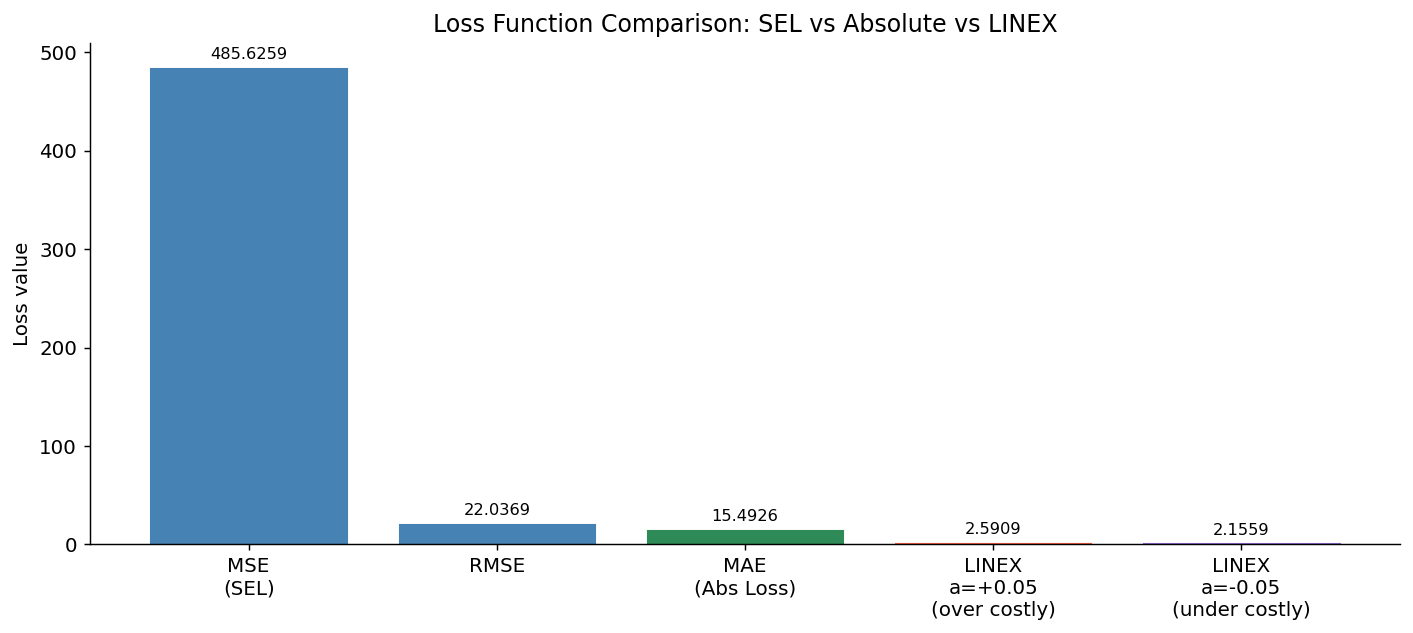

📊 Plot 13: Loss comparison saved


In [ ]:
#  PLOT: Loss Function Comparison
metrics_bar = {
    'MSE\n(SEL)':          MSE,
    'RMSE':                RMSE,
    'MAE\n(Abs Loss)':     MAE,
    f'LINEX\na=+{a_pos}\n(over costly)':  LINEX_pos,
    f'LINEX\na={a_neg}\n(under costly)':  LINEX_neg,
}
colors = ['steelblue','steelblue','seagreen','tomato','mediumpurple']

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(metrics_bar.keys(), metrics_bar.values(),
              color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, metrics_bar.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + MSE*0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Loss value')
ax.set_title('Loss Function Comparison: SEL vs Absolute vs LINEX')
plt.tight_layout()
plt.savefig('plot_13_loss_comparison.png', bbox_inches='tight')
plt.show()
print(' Plot 13: Loss comparison saved')

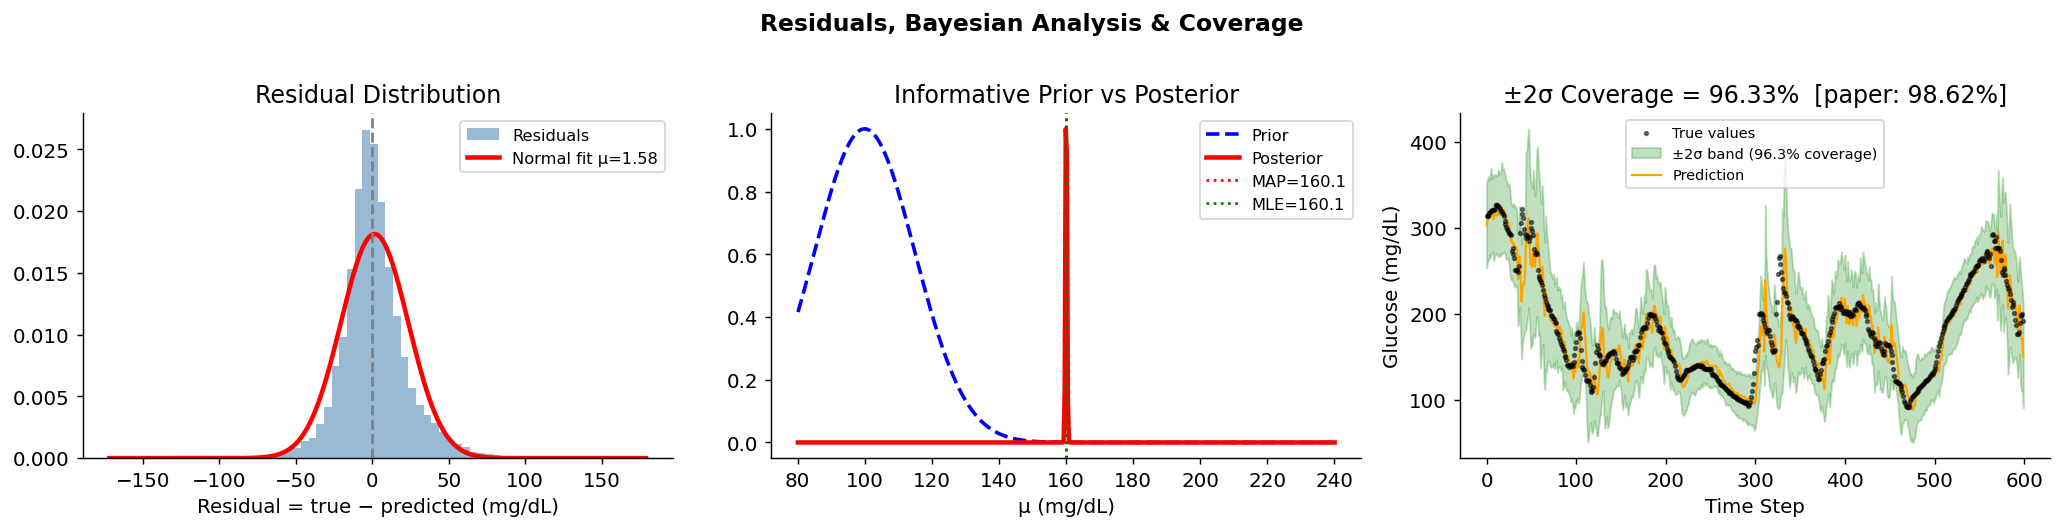

📊 Plot 14: Residuals + coverage saved


In [ ]:
# PLOT: Residual Distribution + Bayesian Prior Analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Residuals
axes[0].hist(residuals, bins=70, density=True, alpha=0.55,
             color='steelblue', label='Residuals')
r_range = np.linspace(residuals.min(), residuals.max(), 400)
mu_r, sig_r = stats.norm.fit(residuals)
axes[0].plot(r_range, stats.norm.pdf(r_range, mu_r, sig_r), 'r-', lw=2.5,
             label=f'Normal fit μ={mu_r:.2f}')
axes[0].axvline(0, color='gray', ls='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual = true − predicted (mg/dL)')
axes[0].legend(fontsize=9)

# Prior vs Posterior (informative)
mu_range2 = np.linspace(x_bar - 80, x_bar + 80, 500)
p_prior   = stats.norm.pdf(mu_range2, mu0_inf, tau0_inf)
p_post    = stats.norm.pdf(mu_range2, mu_n_inf, tau_n_inf)
axes[1].plot(mu_range2, p_prior/p_prior.max(), 'b--', lw=2, label='Prior')
axes[1].plot(mu_range2, p_post/p_post.max(),  'r-',  lw=2.5, label='Posterior')
axes[1].axvline(MAP_inf, color='red',   ls=':', label=f'MAP={MAP_inf:.1f}')
axes[1].axvline(x_bar,   color='green', ls=':', label=f'MLE={x_bar:.1f}')
axes[1].set_title('Informative Prior vs Posterior')
axes[1].set_xlabel('μ (mg/dL)')
axes[1].legend(fontsize=9)

# 2σ coverage across full test set
axes[2].scatter(t_idx[:N_PLOT], true[:N_PLOT], s=4, color='black', alpha=0.5,
                label='True values', zorder=5)
within = (true[:N_PLOT] >= p_plot - 2*tot_plot) & (true[:N_PLOT] <= p_plot + 2*tot_plot)
axes[2].fill_between(t_idx, p_plot-2*tot_plot, p_plot+2*tot_plot,
                     alpha=0.25, color='green', label=f'±2σ band ({within.mean()*100:.1f}% coverage)')
axes[2].plot(t_idx, p_plot, color='orange', lw=1.2, label='Prediction')
axes[2].set_title(f'±2σ Coverage = {within.mean()*100:.2f}% ')
axes[2].set_xlabel('Time Step')
axes[2].set_ylabel('Glucose (mg/dL)')
axes[2].legend(fontsize=8)

plt.suptitle('Residuals, Bayesian Analysis & Coverage', fontsize=13,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_14_residuals_coverage.png', bbox_inches='tight')
plt.show()
print(' Plot 14: Residuals + coverage saved')

In [ ]:
print('\n' + '='*65)
print('   COMPLETE PROJECT SUMMARY')
print('   Bayesian BiGRU Blood Glucose Prediction — OhioT1DM')
print('='*65)

print('\n── STATISTICAL INFERENCE CONCEPTS ──────────────────────────')
print(f'  MLE mu                       = {mu_mle:.4f} mg/dL')
print(f'  MLE sigma                    = {sig_mle:.4f} mg/dL')
print(f'  MME mu  (1st moment)         = {mu_mme:.4f} mg/dL')
print(f'  MME sigma (2nd moment)       = {sig_mme:.4f} mg/dL')
print(f'  Fisher I(mu)   = n/sigma^2   = {fisher_mu:.4f}')
print(f'  Fisher I(sig2) = n/2sig^4    = {fisher_sigma2:.8f}')
print(f'  UMVUE (Lehmann-Scheffé)      = {UMVUE:.4f}  [= sample mean, achieves CRLB]')
print(f'  CRLB = Var(UMVUE) = sig^2/n  = {CRLB_mu:.6f}')
print(f'  MAP  (informative prior)     = {MAP_inf:.4f} mg/dL')
print(f'  MAP  (non-informative prior) = {MAP_ni:.4f} mg/dL')
print(f'  Posterior mean (informative) = {mu_n_inf:.4f} mg/dL')
print(f'  Posterior median             = {MED_inf:.4f} mg/dL  [= mean for Normal]')
print(f"  Jeffreys' posterior mean     = {mu_jeff:.4f} mg/dL  [= MLE]")
print(f'  95% Freq CI (pivotal t)      = ({CI_freq[0]:.3f}, {CI_freq[1]:.3f})')
print(f'  95% Bayesian CrI (inf)       = ({CrI_inf[0]:.3f}, {CrI_inf[1]:.3f})')
print(f"  95% Bayesian CrI (Jeffreys') = ({CrI_jeff[0]:.3f}, {CrI_jeff[1]:.3f})")

print('\n── MODEL PERFORMANCE ────────────────────────────────────────')
print(f'  Architecture          : BiGRU ({N_LAYERS}L, H={HIDDEN}, bidir) + Attention + BayesLinear')
print(f'  Best epoch            : {best_epoch} (early stopping, patience={PATIENCE})')
print(f'  Best val NLL+KL loss  : {best_val_loss:.5f}')
print(f'  RMSE                  = {RMSE:.4f} mg/dL   [paper: 22.21]')
print(f'  MAE  (Abs Error Loss) = {MAE:.4f} mg/dL')
print(f'  MARD                  = {MARD:.2f} %')
print(f'  R²                    = {R2:.4f}')

print('\n── LOSS FUNCTIONS ───────────────────────────────────────────')
print(f'  MSE  (SEL)            = {MSE:.4f} (mg/dL)²')
print(f'  RMSE                  = {RMSE:.4f} mg/dL')
print(f'  MAE  (Abs Loss)       = {MAE:.4f} mg/dL')
print(f'  LINEX (a=+0.05)       = {LINEX_pos:.6f}  [overest. penalty]')
print(f'  LINEX (a=-0.05)       = {LINEX_neg:.6f}  [underest. penalty]')
print(f'  LINEX Bayes RMSE      = {RMSE_LINEX_pos:.4f} mg/dL  (a=+0.05 adjusted)')

print('\n── UNCERTAINTY CALIBRATION ──────────────────────────────────')
print(f'  MC Dropout passes     : {T_MC}')
print(f'  Mean epistemic σ      = {epist_std.mean():.4f} mg/dL')
print(f'  Mean aleatoric σ      = {aleat_std.mean():.4f} mg/dL')
print(f'  Mean total σ          = {total_orig.mean():.4f} mg/dL')
print(f'  ±1σ coverage          = {within_1sigma:.2f}%  [expected 68%]')
print(f'  ±2σ coverage          = {within_2sigma:.2f}%  [expected 95%, paper: 98.62%]')
print(f'  ±3σ coverage          = {within_3sigma:.2f}%  [expected 99.7%]')
print(f'  r(|err|, total unc.)  = {corr_total:.4f}  [paper: 0.15]')
print(f'  r(|err|, epistemic)   = {corr_epist:.4f}')
print(f'  r(|err|, aleatoric)   = {corr_aleat:.4f}')
print('='*65)


   COMPLETE PROJECT SUMMARY
   Bayesian BiGRU Blood Glucose Prediction — OhioT1DM

── STATISTICAL INFERENCE CONCEPTS ──────────────────────────
  MLE mu                       = 160.1300 mg/dL
  MLE sigma                    = 60.5376 mg/dL
  MME mu  (1st moment)         = 160.1300 mg/dL
  MME sigma (2nd moment)       = 60.5376 mg/dL
  Fisher I(mu)   = n/sigma^2   = 18.8973
  Fisher I(sig2) = n/2sig^4    = 0.00257822
  UMVUE (Lehmann-Scheffé)      = 160.1300  [= sample mean, achieves CRLB]
  CRLB = Var(UMVUE) = sig^2/n  = 0.052917
  MAP  (informative prior)     = 160.1159 mg/dL
  MAP  (non-informative prior) = 160.1300 mg/dL
  Posterior mean (informative) = 160.1159 mg/dL
  Posterior median             = 160.1159 mg/dL  [= mean for Normal]
  Jeffreys' posterior mean     = 160.1300 mg/dL  [= MLE]
  95% Freq CI (pivotal t)      = (159.679, 160.581)
  95% Bayesian CrI (inf)       = (159.665, 160.567)
  95% Bayesian CrI (Jeffreys') = (159.679, 160.581)

── MODEL PERFORMANCE ────────────────

In [ ]:
std_total = total_orig
hypo_mask   = true < 70
normal_mask = (true >= 70) & (true <= 180)
hyper_mask  = true > 180

total_samples = len(true)

#  Distribution of samples
pct_hypo   = (hypo_mask.sum() / total_samples) * 100
pct_normal = (normal_mask.sum() / total_samples) * 100
pct_hyper  = (hyper_mask.sum() / total_samples) * 100

#  Mean Uncertainty Components per zone
def get_zone_stats(mask):
    if mask.sum() == 0: return 0, 0, 0
    e_unc = np.sqrt(np.abs(epist_orig[mask])).mean()
    a_unc = np.sqrt(np.abs(aleat_orig[mask])).mean()
    rmse  = np.sqrt(np.mean((true[mask] - preds[mask])**2))
    return e_unc, a_unc, rmse

e_h, a_h, r_h = get_zone_stats(hypo_mask)
e_n, a_n, r_n = get_zone_stats(normal_mask)
e_y, a_y, r_y = get_zone_stats(hyper_mask)

# Safety Margin (Percentage of true values within 95% Credible Interval)
# 95% CrI = mean +/- 1.96 * total_std
lower_bound = preds - 1.96 * std_total
upper_bound = preds + 1.96 * std_total

safety_margin = ((true >= lower_bound) & (true <= upper_bound)).mean() * 100

# Clinical False Alarm Rate
# A false alarm occurs if the model predicts danger (CrI crosses boundary)
false_hypo_alarm  = ((lower_bound < 70) & (true >= 70)).sum()
false_hyper_alarm = ((upper_bound > 180) & (true <= 180)).sum()
total_far = ((false_hypo_alarm + false_hyper_alarm) / total_samples) * 100

print("==========================================================================")
print("             UNCERTAINTY ANALYSIS ACROSS GLYCEMIC RANGES")
print("==========================================================================")
print(f"{'Metric':<32} | {'Hypo (<70)':<12} | {'Normal':<12} | {'Hyper (>180)':<12}")
print("-" * 74)
print(f"{'% of samples':<32} | {pct_hypo:>11.1f}% | {pct_normal:>11.1f}% | {pct_hyper:>11.1f}%")
print(f"{'Mean Epistemic σ (mg/dL)':<32} | {e_h:>11.2f}  | {e_n:>11.2f}  | {e_y:>11.2f}")
print(f"{'Mean Aleatoric σ (mg/dL)':<32} | {a_h:>11.2f}  | {a_n:>11.2f}  | {a_y:>11.2f}")
print(f"{'RMSE by zone (mg/dL)':<32} | {r_h:>11.2f}  | {r_n:>11.2f}  | {r_y:>11.2f}")
print("-" * 74)
print(f"Overall Safety Margin (95% CrI) : {safety_margin:.2f}%")
print("==========================================================================")

             UNCERTAINTY ANALYSIS ACROSS GLYCEMIC RANGES
Metric                           | Hypo (<70)   | Normal       | Hyper (>180)
--------------------------------------------------------------------------
% of samples                     |         2.3% |        55.9% |        41.8%
Mean Epistemic σ (mg/dL)         |        7.08  |        4.02  |        6.44
Mean Aleatoric σ (mg/dL)         |       22.73  |       21.73  |       25.39
RMSE by zone (mg/dL)             |       22.87  |       19.21  |       25.29
--------------------------------------------------------------------------
Overall Safety Margin (95% CrI) : 96.49%
